# 2D Likelihood Contour: CGW Distance vs Pulsar Distance

This notebook generates **N** random pulsars and **M** random continuous
gravitational wave (CGW) sources, then sweeps the PTA log-likelihood over
a 2D grid of:

- **CGW luminosity distance** ($D_L$, in Mpc) of one CW source (x-axis)
- **Pulsar distance** (derived from `PX`, in kpc) of one target pulsar (y-axis)

The CW signal is parameterized internally by the strain $\log_{10} h$. The
distance axis is mapped onto strain with
`jaxpint.pta.signals.cw.log10_strain_from_binary`, which evaluates the
circular-binary strain
$h_0 = 2c\,(G\mathcal{M}/c^3)^{5/3}(\pi f)^{2/3}/D_L$ at a fixed chirp
mass $\mathcal{M}$ (`LOG10_MC`) and the injected GW frequency. Because
$h_0 \propto 1/D_L$, sweeping distance is equivalent to sweeping strain,
just expressed in physical units. (This $h_0$ is the *strain*; the code
applies the extra $1/(2\pi f)$ Detweiler factor internally to get the
residual.)

`PX` is stored as parallax in mas (PINT / `types.py` convention); the
y-axis is displayed in kpc via `d = 1 / PX_mas`, the same conversion
`CWInjector` applies for the Ellis+2012 pulsar-term phase.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.pta.signals.cw import log10_strain_from_binary
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    plot_2d_delta_logL,
    setup_synthetic_pta,
    sweep_1d_logL,
    sweep_2d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 1
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0       # ~8 yr observation span
TOA_ERROR = 1e-8         # 10 ns
FREQ = 1400.0            # MHz
SEED = 42

# CGW source chirp mass used to map luminosity distance -> strain. A 10^9
# Msun SMBH binary; with the injected strain this places the 'true' source
# at a few tens of Mpc.
LOG10_MC = 9.0           # log10 chirp mass (solar masses)

# Likelihood-grid resolution. The pulsar-distance (y) axis is sampled
# finely because the Ellis+2012 pulsar-term phase oscillates rapidly; the
# CGW-distance (x) axis is smooth (broad, non-resonant) and needs far
# fewer points. Bump these up on a GPU.
N_X = 200                # CGW distance grid points
N_Y = 1500               # pulsar distance grid points

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda13.initialize()
Traceback (most recent call last):
  File "/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda13/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda13/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:134: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, and
distance. The par file includes spindown (F0, F1), astrometry (RAJ, DECJ, PX),
and unscaled white noise (EFAC = 1).

In [3]:
rng = np.random.default_rng(SEED)

par_strings = [generate_random_par(idx, rng, start_mjd=START_MJD) for idx in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")

Generated 10 pulsars
Example .par:
PSR           J1834-0701_00
RAJ           18:34:29.80260
DECJ          -07:01:17.6778
F0            443.4391679646
F1            -2.481624e-15
PEPOCH        57000.0
PX            1.359724
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0



## Generate fake TOAs and convert to JaxPINT

In [4]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD, end_mjd=END_MJD,
    n_toas=N_TOAS, toa_error_s=TOA_ERROR, freq_mhz=FREQ,
)
pp_tuple = synthetic.pulsar_params_list

for i, model in enumerate(pint_models):
    px_mas = float(pp_tuple[i].param_value("PX"))
    distance_kpc = 1.0 / px_mas
    f0 = float(pp_tuple[i].param_value("F0"))
    print(
        f"  Pulsar {i}: {model.PSR.value:>20s}  "
        f"PX={px_mas:.3f} mas (d={distance_kpc:.2f} kpc)  F0={f0:.1f} Hz"
    )

print(f"\nAll {N_PULSARS} pulsars loaded.")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 0:        J1834-0701_00  PX=1.360 mas (d=0.74 kpc)  F0=443.4 Hz
  Pulsar 1:        J2324+3129_01  PX=0.615 mas (d=1.63 kpc)  F0=414.4 Hz
  Pulsar 2:        J0853+5835_02  PX=0.622 mas (d=1.61 kpc)  F0=357.5 Hz
  Pulsar 3:        J0527+0616_03  PX=0.481 mas (d=2.08 kpc)  F0=125.5 Hz
  Pulsar 4:        J1811-1654_04  PX=0.409 mas (d=2.45 kpc)  F0=488.3 Hz
  Pulsar 5:        J0440-0348_05  PX=0.453 mas (d=2.21 kpc)  F0=117.5 Hz
  Pulsar 6:        J1752+6913_06  PX=0.597 mas (d=1.67 kpc)  F0=230.3 Hz
  Pulsar 7:        J0432-4744_07  PX=0.460 mas (d=2.17 kpc)  F0=290.3 Hz
  Pulsar 8:        J1029+4142_08  PX=0.387 mas (d=2.58 kpc)  F0=380.1 Hz
  Pulsar 9:        J1918-1300_09  PX=1.177 mas (d=0.85 kpc)  F0=215.3 Hz

All 10 pulsars loaded.


## Set up M CW sources and inject into TOAs

We place M continuous gravitational wave sources at random sky locations with
random nHz-band GW frequencies and strain amplitude $h = 10^{-14}$. The
injected strain, together with the chosen chirp mass and frequency, fixes a
physical luminosity distance for the source (computed below).

In [5]:
cw_injectors, _ = build_cw_injectors(
    pint_models, n_sources=M_CW_SOURCES, rng=rng, log10_h=-14.0,
)

for m, inj in enumerate(cw_injectors):
    print(
        f"  CW source {m}: cos_gwtheta={inj.param_spec['cos_gwtheta']:.3f}, "
        f"gwphi={inj.param_spec['gwphi']:.3f}, "
        f"log10_fgw={inj.param_spec['log10_fgw']:.2f}"
    )

gp, config = inject_and_build_config(synthetic, cw_injectors)

# True injected strain and frequency of source 0.
TRUE_LOG10_H = float(cw_injectors[0].param_spec["log10_h"])
TRUE_LOG10_FGW = float(cw_injectors[0].param_spec["log10_fgw"])

print(f"\nPTA config built with {M_CW_SOURCES} CW sources.")
print(f"Global params: {gp.names}")

  CW source 0: cos_gwtheta=-0.600, gwphi=0.046, log10_fgw=-7.43



PTA config built with 1 CW sources.
Global params: ('cw0_log10_h', 'cw0_cos_gwtheta', 'cw0_gwphi', 'cw0_log10_fgw', 'cw0_cos_inc', 'cw0_psi', 'cw0_phase0')


## 2D likelihood sweep: CGW distance vs pulsar distance

We sweep the CGW luminosity distance of source 0 (mapped to `cw0_log10_h`
at fixed `LOG10_MC` and the injected frequency) and the distance of pulsar 0
(`PX`) over a 2D grid, evaluating the PTA log-likelihood at each point.

Note: the pulsar-distance (y) window is kept narrow — the pulsar-term phase
oscillates rapidly with distance. The CGW-distance (x) direction, like strain,
is broad and non-resonant, so a wider window in $\log_{10} D_L$ is used.

In [6]:
TARGET_PULSAR = 0
true_px_mas = float(pp_tuple[TARGET_PULSAR].param_value("PX"))
true_distance = 1.0 / true_px_mas  # kpc (pulsar distance, y-axis)
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc "
      f"(PX = {true_px_mas:.4f} mas)")

# Map the injected strain to a 'true' CGW luminosity distance at fixed chirp
# mass and the injected GW frequency. Since h0 ∝ 1/D_L, the strain at 1 Mpc
# fixes the offset:  log10_h = log10_h(1 Mpc) - log10(D_L / Mpc).
log10_h_at_1mpc = float(log10_strain_from_binary(LOG10_MC, 0.0, TRUE_LOG10_FGW))
true_log10_dist = log10_h_at_1mpc - TRUE_LOG10_H
true_dist_mpc = 10.0 ** true_log10_dist
print(f"True CGW luminosity distance: {true_dist_mpc:.3f} Mpc "
      f"(log10 D_L = {true_log10_dist:.3f}, M_c = 10^{LOG10_MC:.1f} Msun, "
      f"log10_h = {TRUE_LOG10_H:.2f})")

# y-axis: pulsar distance window (kpc), inverted to mas for the sweep so the
# likelihood receives physically correct parallax values.
half_window_px = 0.005           # kpc
distance_grid = np.linspace(
    true_distance - half_window_px,
    true_distance + half_window_px,
    N_Y,
)
px_mas_grid = 1.0 / distance_grid

# x-axis: CGW luminosity distance, swept in log10 over +/- 0.5 dex.
half_window_logdist = 0.5        # dex
log10_dist_grid = np.linspace(
    true_log10_dist - half_window_logdist,
    true_log10_dist + half_window_logdist,
    N_X,
)

def eval_logL_2d(log10_dist_val, px_mas_val):
    log10_h_val = log10_strain_from_binary(LOG10_MC, log10_dist_val, TRUE_LOG10_FGW)
    gp_mod = gp.with_value("cw0_log10_h", log10_h_val)
    pp_mod_0 = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_val)
    pp_mod = pp_tuple[:TARGET_PULSAR] + (pp_mod_0,) + pp_tuple[TARGET_PULSAR + 1:]
    return pta_logL(gp_mod, pp_mod, config)

print(f"Computing {N_X} x {N_Y} = {N_X * N_Y} likelihood evaluations...")
logL_2d = sweep_2d_logL(eval_logL_2d, log10_dist_grid, px_mas_grid)
print("Done.")

Pulsar 0 true distance: 0.735 kpc (PX = 1.3597 mas)
True CGW luminosity distance: 66.565 Mpc (log10 D_L = 1.823, M_c = 10^9.0 Msun, log10_h = -14.00)
Computing 200 x 1500 = 300000 likelihood evaluations...


Done.


## Colormesh plot

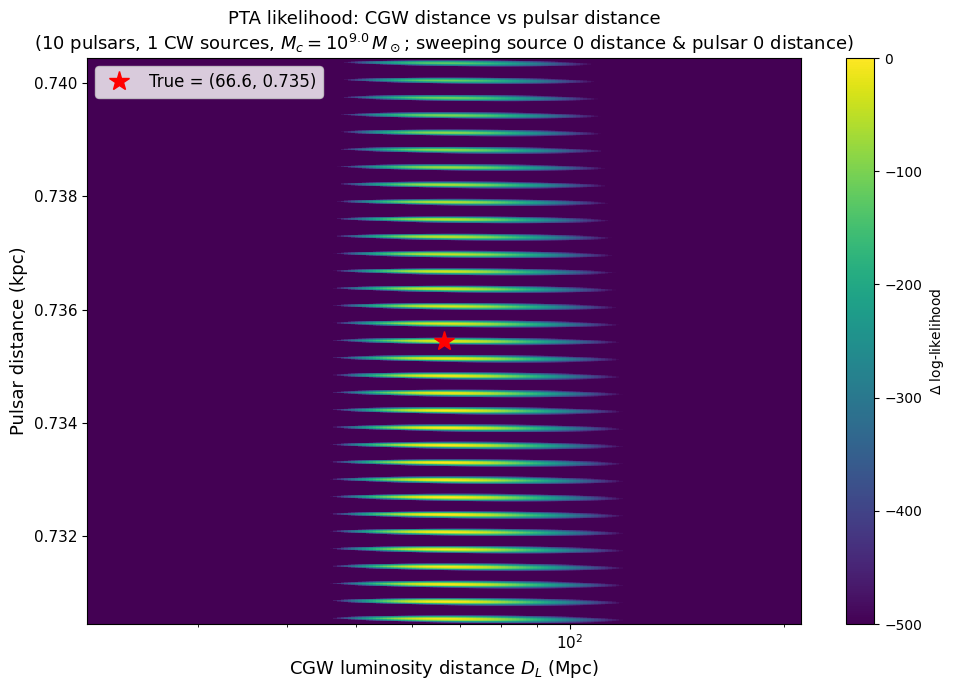

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

# logL_2d is shaped (n_y=len(px_mas_grid), n_x=len(log10_dist_grid)); rows
# follow px_mas_grid (descending in kpc). Flip to present kpc ascending.
distance_grid_plot = distance_grid[::-1]
logL_2d_plot = logL_2d[::-1, :]

# x-axis displayed as luminosity distance in Mpc (log scale).
dist_mpc_grid = 10.0 ** log10_dist_grid

mesh = plot_2d_delta_logL(
    ax, dist_mpc_grid, distance_grid_plot, logL_2d_plot,
    true_xy=(true_dist_mpc, true_distance),
)
ax.set_xscale("log")
ax.set_xlabel(r"CGW luminosity distance $D_L$ (Mpc)", fontsize=13)
ax.set_ylabel("Pulsar distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA likelihood: CGW distance vs pulsar distance\n"
    f"({N_PULSARS} pulsars, {M_CW_SOURCES} CW sources, "
    f"$M_c=10^{{{LOG10_MC:.1f}}}\\,M_\\odot$; sweeping source 0 distance "
    f"& pulsar {TARGET_PULSAR} distance)",
    fontsize=13,
)
ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=11)
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()

## 1D likelihood sweep: CGW distance at true pulsar distance

Slice through the 2D surface at the true pulsar distance to show how the
likelihood depends on CGW luminosity distance alone. Because $h_0 \propto
1/D_L$, this is the strain likelihood re-expressed in distance.

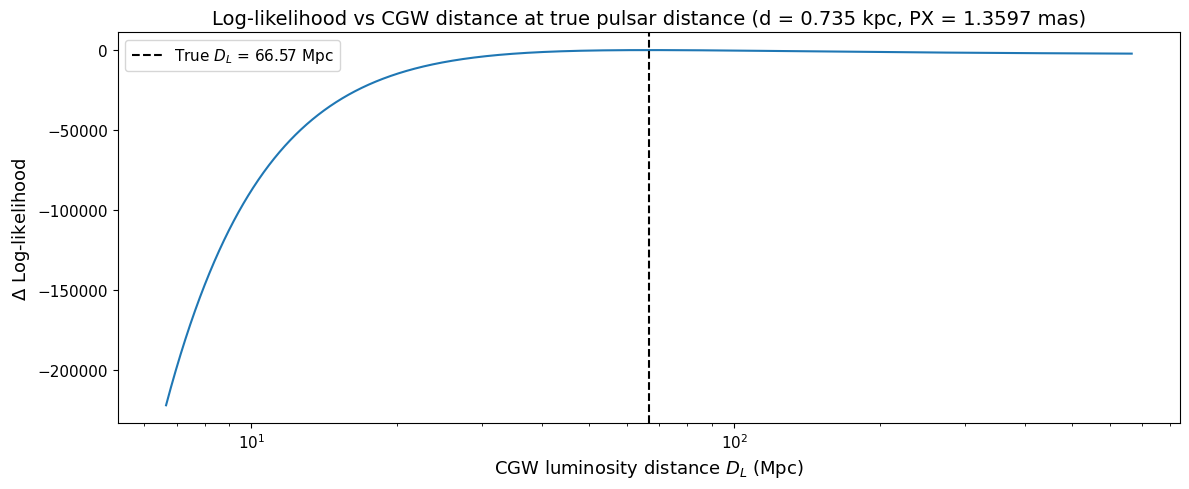

In [8]:
half_window_logdist_1 = 1.0      # dex
log10_dist_fine = np.linspace(
    true_log10_dist - half_window_logdist_1,
    true_log10_dist + half_window_logdist_1,
    2000,
)

def _eval_1d(log10_dist_val, _px_mas=jnp.float64(true_px_mas)):
    return eval_logL_2d(log10_dist_val, _px_mas)

logL_1d = sweep_1d_logL(_eval_1d, log10_dist_fine)
delta_1d = logL_1d - logL_1d.max()

fig, ax = plt.subplots(figsize=(12, 5))
dist_mpc_fine = 10.0 ** log10_dist_fine
ax.plot(dist_mpc_fine, delta_1d, linewidth=1.5)
ax.axvline(
    true_dist_mpc, color="black", linestyle="--", linewidth=1.5,
    label=f"True $D_L$ = {true_dist_mpc:.2f} Mpc",
)
ax.set_xscale("log")
ax.set_xlabel(r"CGW luminosity distance $D_L$ (Mpc)", fontsize=13)
ax.set_ylabel(r"$\Delta$ Log-likelihood", fontsize=13)
ax.set_title(
    f"Log-likelihood vs CGW distance at true pulsar distance "
    f"(d = {true_distance:.3f} kpc, PX = {true_px_mas:.4f} mas)",
    fontsize=14,
)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()